# A Física do Fenómeno: Cristiano Ronaldo
--- 
Este notebook simula e analisa matematicamente duas das proezas físicas mais famosas de Cristiano Ronaldo: **O Salto Vertical (Manchester United, 2013)** e **O Livre em Knuckleball (Arsenal, 2009)**.

## 1. Cinemática do Salto Vertical (Hang-Time)
Utilizando a equação do movimento uniformemente variado, determinamos a altura do centro de massa ao longo do tempo:
$$y(t) = y_0 + v_0 t - \frac{1}{2}gt^2$$

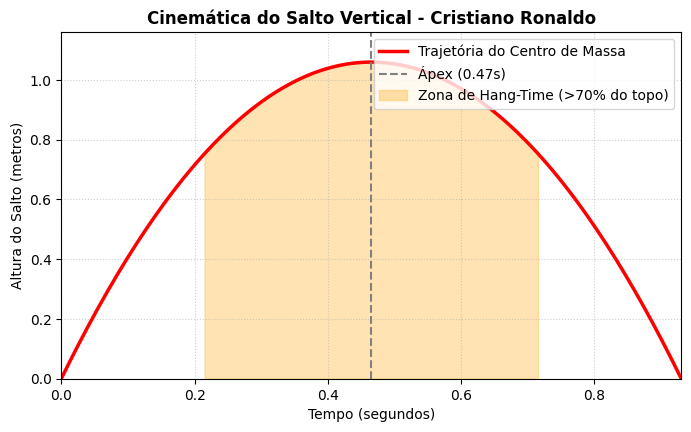

Velocidade de descolagem calculada: 4.56 m/s (16.4 km/h)
Tempo total no ar (Hang-time): 0.93 segundos


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do Salto (Man. United 2013)
g = 9.8         # Aceleração gravítica (m/s^2)
delta_y = 1.06  # Altura líquida do salto (m)
v0 = np.sqrt(2 * g * delta_y) # Velocidade de descolagem (m/s)
t_subida = v0 / g
t_total = 2 * t_subida

# Vetor tempo (subida e descida)
t = np.linspace(0, t_total, 200)
y = v0 * t - 0.5 * g * t**2

# Gráfico da Trajetória Vertical
plt.figure(figsize=(8, 4.5))
plt.plot(t, y, 'r-', linewidth=2.5, label='Trajetória do Centro de Massa')
plt.axvline(x=t_subida, color='gray', linestyle='--', label=f'Ápex ({t_subida:.2f}s)')
plt.fill_between(t, y, where=(y > delta_y * 0.7), color='orange', alpha=0.3, label='Zona de Hang-Time (>70% do topo)')

plt.title('Cinemática do Salto Vertical - Cristiano Ronaldo', fontsize=12, fontweight='bold')
plt.xlabel('Tempo (segundos)', fontsize=10)
plt.ylabel('Altura do Salto (metros)', fontsize=10)
plt.xlim(0, t_total)
plt.ylim(0, delta_y + 0.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

print(f"Velocidade de descolagem calculada: {v0:.2f} m/s ({v0*3.6:.1f} km/h)")
print(f"Tempo total no ar (Hang-time): {t_total:.2f} segundos")

## 2. Aerodinâmica do Livre em Knuckleball
Quando a bola viaja sem rotação, as forças laterais sustentadoras ($F_L$) oscilam caoticamente à medida que a esteira turbulenta se desprende das costuras. Vamos simular este desvio tridimensional errático adicionando uma força lateral estocástica (caótica) à trajetória linear.

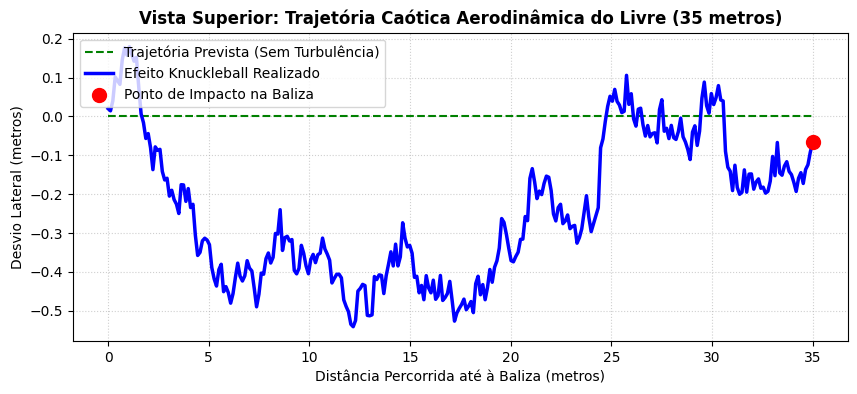

Tempo de voo da bola até cruzar a linha: 1.22 segundos
Desvio lateral final gerado pelas oscilações de pressão: 0.07 metros


In [2]:
# Parâmetros do remate (Arsenal 2009)
v_b = 28.61     # Velocidade inicial (103 km/h em m/s)
distancia = 35  # Distância à baliza (m)
t_voo = distancia / v_b

x = np.linspace(0, distancia, 300)
y_ideal = np.zeros_like(x) # Trajetória retilínea de referência

# Simulação do desvio caótico lateral (Knuckleball)
np.random.seed(42) # Fixar a semente para repetibilidade
ruido_caotico = np.cumsum(np.random.normal(0, 0.04, len(x)))
y_knuckleball = y_ideal + ruido_caotico

# Gráfico do Efeito de Desvio Lateral
plt.figure(figsize=(10, 4))
plt.plot(x, y_ideal, 'g--', label='Trajetória Prevista (Sem Turbulência)')
plt.plot(x, y_knuckleball, 'b-', linewidth=2.5, label='Efeito Knuckleball Realizado')
plt.scatter(distancia, y_knuckleball[-1], color='red', s=100, zorder=5, label='Ponto de Impacto na Baliza')

plt.title('Vista Superior: Trajetória Caótica Aerodinâmica do Livre (35 metros)', fontsize=12, fontweight='bold')
plt.xlabel('Distância Percorrida até à Baliza (metros)', fontsize=10)
plt.ylabel('Desvio Lateral (metros)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

print(f"Tempo de voo da bola até cruzar a linha: {t_voo:.2f} segundos")
print(f"Desvio lateral final gerado pelas oscilações de pressão: {abs(y_knuckleball[-1]):.2f} metros")